# Probabilidade, Distribuições, Testes Estatísticos e Modelos — Ibovespa

**Atividade:** Probabilidade · Distribuições discretas e contínuas · Assimetria e curtose · Testes estatísticos · Modelos  
**Dataset:** Retornos diários do Ibovespa (^BVSP) — 2000 a 2025  
**Fonte:** Yahoo Finance via `yfinance`

---

## Contexto

Gerenciar risco no mercado de capitais é, fundamentalmente, gerenciar **incerteza**. A linguagem matemática da incerteza é a probabilidade — e das probabilidades nascem as distribuições, os testes e os modelos.

Este notebook percorre esse caminho em seis etapas:

| Seção | Pergunta respondida |
|-------|---------------------|
| **Probabilidade** | Como quantifico a chance de um evento ocorrer? |
| **Distribuições discretas** | Como modelo eventos contáveis — dias positivos, crashes, defaults? |
| **Distribuições contínuas** | Como modelo grandezas contínuas — retornos, volatilidade? |
| **Forma das distribuições** | Os dados são simétricos? As caudas são pesadas? |
| **Testes estatísticos** | Como valido hipóteses sobre os dados com rigor matemático? |
| **Modelos** | Quando usar estatística clássica e quando usar machine learning? |

Todos os conceitos são aplicados diretamente aos retornos diários do Ibovespa.

## 1. Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import yfinance as yf
import warnings
from scipy import stats
from scipy.stats import norm, t as t_dist, binom, bernoulli, poisson
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (11, 4)
sns.set_theme(style="whitegrid", palette="muted")

## 2. Dados

In [2]:
ibov = yf.download("^BVSP", start="2000-01-01", end="2025-03-31", auto_adjust=True)
preco   = ibov["Close"].dropna()
retorno = preco.pct_change().dropna()
ret     = retorno.values.flatten()

print(f"Período  : {preco.index[0].date()} → {preco.index[-1].date()}")
print(f"Pregões  : {len(preco):,}")
print(f"Retornos : {len(ret):,}")
print(f"\nMédia diária : {ret.mean()*100:.4f}%")
print(f"Desvio padrão: {ret.std()*100:.4f}%")
print(f"Mínimo / Máx : {ret.min()*100:.2f}% / {ret.max()*100:.2f}%")

[*********************100%***********************]  1 of 1 completed

Período  : 2000-01-03 → 2025-03-28
Pregões  : 6,251
Retornos : 6,250

Média diária : 0.0476%
Desvio padrão: 1.7180%
Mínimo / Máx : -14.78% / 14.66%


### Lendo os Dados

Os **6.250 retornos diários** do Ibovespa entre 2000 e 2025 formam a base empírica de todo o notebook. Antes de qualquer análise probabilística, vale entender o que os três números resumidos revelam:

| Estatística | Valor | Interpretação |
|-------------|-------|---------------|
| **Média diária** | +0.0476% | Equivale a ~+12% ao ano — retorno esperado positivo no longo prazo, mas quase imperceptível dia a dia |
| **Desvio padrão** | 1.718% | ~**27% ao ano** (1.718% × √252) — é a **volatilidade histórica anualizada do Ibovespa**, a medida central de risco de mercado |
| **Mínimo** | −14.78% | Queda de um único pregão — provavelmente **março de 2020** (COVID) ou **outubro de 2008** (Lehman Brothers) |
| **Máximo** | +14.66% | Alta de um único pregão — tipicamente dias de recuperação após quedas abruptas |

> A proximidade entre o mínimo (−14.78%) e o máximo (+14.66%) sugere que as piores quedas e as maiores altas têm magnitudes similares. Mas a **frequência** com que os extremos negativos ocorrem é ligeiramente maior — algo que as seções de curtose (6.2) e testes estatísticos (7) irão confirmar matematicamente.

## 3. Probabilidade — A Linguagem da Incerteza

### 3.1 Espaço Amostral e Eventos

O **espaço amostral** $\Omega$ é o conjunto de todos os resultados possíveis de um experimento aleatório.

Um **evento** $A$ é qualquer subconjunto do espaço amostral: $A \subseteq \Omega$.

Uma função $P(\cdot)$ é chamada de **probabilidade** se satisfaz os três axiomas de Kolmogorov:

$$\text{(i) } 0 \leq P(A) \leq 1 \qquad \text{(ii) } P(\Omega) = 1 \qquad \text{(iii) } P\!\left(\bigcup_{j} A_j\right) = \sum_j P(A_j) \text{ se } A_j \text{ disjuntos}$$

onde $A$ é um evento qualquer, $\Omega$ é o espaço amostral completo e $A_j$ são eventos mutuamente disjuntos — ou seja, não podem ocorrer ao mesmo tempo (por exemplo, "dia de alta" e "dia de queda" são disjuntos).

**Aplicação ao Ibovespa:**

| Elemento | Definição | Exemplo |
|----------|-----------|----------|
| Experimento | Observar o retorno do pregão de amanhã | — |
| $\Omega$ | Todos os retornos diários possíveis | $(-100\%, +\infty)$ |
| Evento $A$ | Retorno positivo | $A = \{r > 0\}$ |
| Evento $B$ | Queda maior que 3% | $B = \{r < -0{,}03\}$ |

Na prática, os axiomas garantem coerência: a probabilidade de "o Ibovespa subir ou cair em algum percentual" é sempre 1 (algo vai acontecer), e a probabilidade de qualquer evento específico está sempre entre 0 e 100%.

---

### 3.2 Probabilidade Clássica vs. Empírica

**Clássica (Laplaciana)** — pressupõe resultados equiprováveis:

$$P(A) = \frac{|A|}{|\Omega|} = \frac{\text{casos favoráveis a } A}{\text{total de casos igualmente prováveis}}$$

onde $|A|$ é o número de casos favoráveis ao evento $A$ e $|\Omega|$ é o número total de resultados possíveis, todos com a mesma chance de ocorrer.

Funciona para dados, moedas e urnas — onde todos os resultados são, por construção, equiprováveis. Em finanças, retornos de +5% e de +0,01% **não** têm a mesma probabilidade, logo essa abordagem não se aplica diretamente.

**Empírica (Frequentista)** — estima a probabilidade pela frequência relativa observada:

$$P(A) \approx \frac{n_A}{n}$$

onde $n_A$ é o número de vezes que $A$ ocorreu em $n$ experimentos. É a abordagem natural para análise de risco: com os 6.250 pregões do Ibovespa, calculamos $P(\text{queda} > 3\%)$ simplesmente contando quantas vezes isso aconteceu e dividindo pelo total. Quanto maior a série histórica, mais confiável a estimativa.

**Subjetiva** — grau de crença pessoal sobre a ocorrência de um evento, expresso como um número entre 0 e 1. Não exige repetição do experimento — é válida mesmo para eventos únicos. Exemplo: a probabilidade que um gestor de risco atribui a uma crise sistêmica nos próximos 12 meses, com base na sua leitura do ambiente macroeconômico. É a base da inferência Bayesiana.

Probabilidades empíricas — Ibovespa (2000-2025):
  P(retorno > 0)      = 0.5171  (51.7%)
  P(retorno < 0)      = 0.4822  (48.2%)
  P(retorno < −3%)    = 0.0355  (3.55%)
  P(retorno > +3%)    = 0.0330  (3.30%)
  P(|retorno| > 5%)   = 0.0125  (1.25%)

Propriedades verificadas:
  P(r > 0) + P(r < 0) + P(r = 0) = 1.0000  [axioma ii: P(Ω) = 1]
  P(queda > 3% OU alta > 3%) = 0.0685  [disjuntos → soma direta]


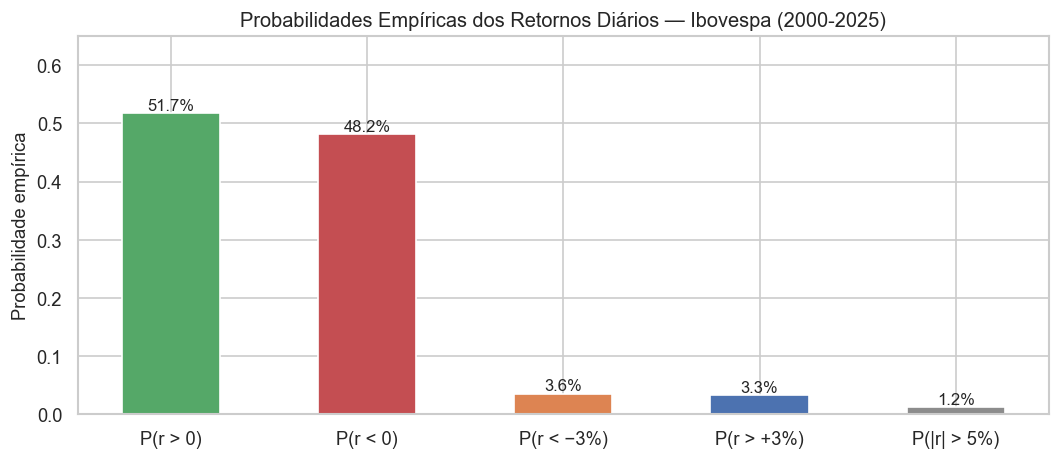

In [3]:
# Probabilidades empíricas diretas dos retornos do Ibovespa
p_pos    = (ret > 0).mean()
p_neg    = (ret < 0).mean()
p_queda3 = (ret < -0.03).mean()
p_alta3  = (ret >  0.03).mean()
p_ext5   = (np.abs(ret) > 0.05).mean()

print("Probabilidades empíricas — Ibovespa (2000-2025):")
print(f"  P(retorno > 0)      = {p_pos:.4f}  ({p_pos*100:.1f}%)")
print(f"  P(retorno < 0)      = {p_neg:.4f}  ({p_neg*100:.1f}%)")
print(f"  P(retorno < −3%)    = {p_queda3:.4f}  ({p_queda3*100:.2f}%)")
print(f"  P(retorno > +3%)    = {p_alta3:.4f}  ({p_alta3*100:.2f}%)")
print(f"  P(|retorno| > 5%)   = {p_ext5:.4f}  ({p_ext5*100:.2f}%)")

# Propriedades de probabilidade
print(f"\nPropriedades verificadas:")
print(f"  P(r > 0) + P(r < 0) + P(r = 0) = {p_pos + p_neg + (ret==0).mean():.4f}  [axioma ii: P(Ω) = 1]")
print(f"  P(queda > 3% OU alta > 3%) = {p_queda3 + p_alta3:.4f}  [disjuntos → soma direta]")

# Visualização
labels = ["P(r > 0)", "P(r < 0)", "P(r < −3%)", "P(r > +3%)", "P(|r| > 5%)"]
vals   = [p_pos, p_neg, p_queda3, p_alta3, p_ext5]
cores  = ["#55A868", "#C44E52", "#DD8452", "#4C72B0", "#8C8C8C"]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, vals, color=cores, edgecolor="white", width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
            f"{v*100:.1f}%", ha="center", fontsize=10)
ax.set_ylabel("Probabilidade empírica", fontsize=11)
ax.set_title("Probabilidades Empíricas dos Retornos Diários — Ibovespa (2000-2025)", fontsize=12)
ax.set_ylim(0, 0.65)
plt.tight_layout()
plt.show()

### 3.3 Probabilidade Condicional

A probabilidade condicional $P(A \mid B)$ é a probabilidade de $A$ ocorrer **dado que $B$ já ocorreu**. Ao saber que $B$ aconteceu, reduzimos o espaço amostral para os resultados compatíveis com $B$:

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

onde $P(A \cap B)$ é a probabilidade de $A$ e $B$ ocorrerem simultaneamente, $P(B)$ é a probabilidade marginal de $B$ e a condição $P(B) > 0$ garante que o condicionamento seja válido (não faz sentido condicionar a um evento impossível).

**Aplicação em risco:** sabendo que o Ibovespa caiu mais de 2% ontem (evento $B$), qual a probabilidade de cair mais de 2% hoje também (evento $A$)? Responder isso sem a condicional nos levaria a subestimar o risco em períodos de crise — momentos em que quedas tendem a se agrupar (clustering de volatilidade).

---

### 3.4 Eventos Independentes e Dependentes

Dois eventos são **independentes** se o conhecimento de um não altera a probabilidade do outro:

$$A \perp B \iff P(A \mid B) = P(A) \iff P(A \cap B) = P(A) \cdot P(B)$$

São **dependentes** quando:

$$P(A \mid B) \neq P(A) \iff P(A \cap B) \neq P(A) \cdot P(B)$$

**Em mercados eficientes**, o retorno de amanhã seria independente do de hoje — o passado não prevê o futuro. Na prática, em períodos normais essa independência é razoavelmente válida para retornos diários. Mas durante crises — como a de 2008, a queda do COVID em 2020, ou o circuit breaker de março de 2020 — os retornos se tornam claramente **dependentes**: quedas geram mais quedas, e o modelo de independência subestima drasticamente o risco.

Essa dependência temporal na volatilidade é a razão de ser dos modelos GARCH: eles modelam explicitamente o fato de que dias de alta volatilidade tendem a ser seguidos por outros dias de alta volatilidade.

---

### 3.5 Teorema de Bayes

O Teorema de Bayes formaliza a **atualização de crenças** à luz de novas evidências:

$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

onde $P(A)$ é a crença inicial (*prior*) antes de observar $B$, $P(B \mid A)$ é a verossimilhança — quão provável seria observar $B$ se $A$ fosse verdadeiro, $P(B)$ é a probabilidade total de observar $B$ (evidência) e $P(A \mid B)$ é a crença atualizada (*posterior*) após observar $B$.

| Termo | Nome | Interpretação em risco |
|-------|------|------------------------|
| $P(A)$ | *Prior* | Probabilidade histórica de queda no dia seguinte |
| $P(B \mid A)$ | Verossimilhança | P(hoje caiu \| amanhã também vai cair) |
| $P(B)$ | Evidência | Probabilidade marginal de queda hoje |
| $P(A \mid B)$ | *Posterior* | Probabilidade revisada de queda amanhã, dado que hoje caiu |

**Aplicação prática:** um modelo bayesiano de risco começa com uma crença sobre a volatilidade do mercado (*prior* baseado em dados históricos) e atualiza essa crença continuamente à medida que novos pregões chegam. Se o Ibovespa cair 5% hoje, a probabilidade de uma queda amanhã sobe — o *posterior* incorpora essa informação. Isso é exatamente o que modelos como o DCC-GARCH fazem de forma implícita.

O Bayesianismo é mais do que um teorema — é uma **filosofia estatística**: todo parâmetro desconhecido tem uma distribuição de probabilidade, e essa distribuição é continuamente atualizada com novos dados.

In [4]:
hoje   = ret[1:]
ontem  = ret[:-1]

# --- Probabilidade condicional ---
p_hpos_dado_opos = (hoje[ontem > 0] > 0).mean()
p_hpos_dado_oneg = (hoje[ontem < 0] > 0).mean()
p_hpos           = (hoje > 0).mean()

print("Probabilidade Condicional:")
print(f"  P(hoje > 0 | ontem > 0) = {p_hpos_dado_opos:.4f}  ({p_hpos_dado_opos*100:.1f}%)")
print(f"  P(hoje > 0 | ontem < 0) = {p_hpos_dado_oneg:.4f}  ({p_hpos_dado_oneg*100:.1f}%)")
print(f"  P(hoje > 0) marginal    = {p_hpos:.4f}  ({p_hpos*100:.1f}%)")
print(f"  Diferença |cond1 - cond2|: {abs(p_hpos_dado_opos - p_hpos_dado_oneg)*100:.1f} pp")

# --- Independência: P(A ∩ B) vs P(A)·P(B) ---
p_a    = (hoje > 0).mean()
p_b    = (ontem > 0).mean()
p_conj = ((hoje > 0) & (ontem > 0)).mean()
p_ind  = p_a * p_b

print(f"\nIndependência:")
print(f"  P(A∩B) observado         = {p_conj:.4f}")
print(f"  P(A)·P(B) se indep.      = {p_ind:.4f}")
print(f"  Diferença                = {abs(p_conj - p_ind):.4f}")
if abs(p_conj - p_ind) < 0.01:
    print("  → Dias consecutivos são aproximadamente independentes (mercado eficiente).")
else:
    print("  → Dependência detectada entre dias consecutivos.")

# --- Teorema de Bayes: P(queda amanhã | queda hoje) ---
p_qa   = (ret[1:] < 0).mean()          # P(A) = prior: queda amanhã
p_qh   = (ret[:-1] < 0).mean()         # P(B) = queda hoje
p_qh_dado_qa = (ret[:-1][ret[1:] < 0] < 0).mean()  # P(B|A)
p_qa_dado_qh = (p_qh_dado_qa * p_qa) / p_qh         # Posterior via Bayes

print(f"\nAtualização Bayesiana — P(queda amanhã | queda hoje):")
print(f"  Prior  P(A) = {p_qa:.4f}  ({p_qa*100:.1f}%)")
print(f"  P(B|A)      = {p_qh_dado_qa:.4f}  ({p_qh_dado_qa*100:.1f}%)")
print(f"  Posterior P(A|B) via Bayes = {p_qa_dado_qh:.4f}  ({p_qa_dado_qh*100:.1f}%)")
delta = (p_qa_dado_qh - p_qa) * 100
print(f"  Variação prior → posterior: {delta:+.1f} pp")
print("  → Observar queda hoje provoca mudança mínima na crença sobre amanhã.")

Probabilidade Condicional:
  P(hoje > 0 | ontem > 0) = 0.5118  (51.2%)
  P(hoje > 0 | ontem < 0) = 0.5227  (52.3%)
  P(hoje > 0) marginal    = 0.5172  (51.7%)
  Diferença |cond1 - cond2|: 1.1 pp

Independência:
  P(A∩B) observado         = 0.2647
  P(A)·P(B) se indep.      = 0.2675
  Diferença                = 0.0028
  → Dias consecutivos são aproximadamente independentes (mercado eficiente).

Atualização Bayesiana — P(queda amanhã | queda hoje):
  Prior  P(A) = 0.4822  (48.2%)
  P(B|A)      = 0.4769  (47.7%)
  Posterior P(A|B) via Bayes = 0.4769  (47.7%)
  Variação prior → posterior: -0.5 pp
  → Observar queda hoje provoca mudança mínima na crença sobre amanhã.


> **Conexão:** probabilidade é a ferramenta. O próximo passo é entender os **modelos matemáticos** que descrevem como eventos aleatórios se distribuem — começando pelos discretos, onde os resultados são contáveis.

## 4. Distribuições de Probabilidade Discretas

Uma **distribuição discreta** modela variáveis que assumem valores inteiros e contáveis — ao contrário das contínuas, onde qualquer valor em um intervalo é possível. As três mais importantes em análise de risco são Bernoulli, Binomial e Poisson.

---

### 4.1 Distribuição de Bernoulli

É o caso mais simples: um único experimento com dois resultados possíveis — **sucesso** ($X=1$, probabilidade $p$) ou **fracasso** ($X=0$, probabilidade $1-p$).

$$P(X = k) = p^k (1-p)^{1-k}, \quad k \in \{0, 1\}$$

onde $p \in (0, 1)$ é a probabilidade de sucesso (o parâmetro da distribuição), $1-p$ é a probabilidade de fracasso e $k$ é o resultado observado — 1 para sucesso, 0 para fracasso.

**Parâmetros:**
- $\mathbb{E}[X] = p$ — o valor esperado é a própria probabilidade de sucesso
- $\text{Var}(X) = p(1-p)$ — a variância é máxima quando $p = 0{,}5$ (máxima incerteza)

**Aplicação:** cada pregão do Ibovespa é, em sua forma mais simples, uma variável de Bernoulli — o pregão fecha em alta ($X=1$) com probabilidade $p \approx 0{,}517$ ou em queda ($X=0$) com probabilidade $1-p \approx 0{,}483$. Um trader pode usar isso para calcular a probabilidade de uma série de stops consecutivos, ou um gestor para estimar a frequência esperada de dias ruins em um período.

---

### 4.2 Distribuição Binomial

É a **soma de $n$ variáveis de Bernoulli independentes** com o mesmo $p$. Modela o número de sucessos $k$ em $n$ tentativas:

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k \in \{0, 1, \ldots, n\}$$

onde $n$ é o número total de tentativas (pregões), $k$ é o número de sucessos que queremos calcular a probabilidade, $p$ é a probabilidade de sucesso em cada tentativa individual e $\binom{n}{k} = \dfrac{n!}{k!(n-k)!}$ é o coeficiente binomial — o número de formas distintas de obter exatamente $k$ sucessos em $n$ tentativas.

**Parâmetros:**
- $\mathbb{E}[X] = np$ — esperamos $np$ sucessos em média
- $\text{Var}(X) = np(1-p)$

**Aplicação:** em um ano de $n = 252$ pregões, com $p \approx 0{,}517$, esperamos cerca de 130 dias positivos. A Binomial nos diz também a probabilidade de ter menos de 110 ou mais de 150 dias positivos — informação relevante para avaliar se um fundo está com desempenho estatisticamente acima ou abaixo do esperado pelo acaso.

---

### 4.3 Bimodal ≠ Binomial — Uma Confusão Comum

Esses dois termos parecem similares, mas designam conceitos completamente diferentes:

| Termo | O que é | Natureza |
|-------|---------|----------|
| **Binomial** | Distribuição de probabilidade discreta: modela o número de sucessos em $n$ tentativas independentes | Probabilístico — é um modelo matemático específico |
| **Bimodal** | Qualquer distribuição que apresenta **dois picos** (duas modas) na sua curva de densidade | Descritivo — descreve apenas a *forma* de uma distribuição, qualquer que seja |

Uma distribuição **bimodal** pode ser normal, uniforme, contínua ou discreta — o que a define é ter dois máximos locais na curva de densidade. Em finanças, retornos bimodais costumam indicar dois **regimes de mercado** distintos: bull market (alta e baixa volatilidade concentradas em torno de um retorno positivo) e bear market (retornos negativos com volatilidade elevada). A mistura dessas duas populações em uma série histórica longa pode produzir bimodalidade.

Uma distribuição **binomial** é um modelo específico para contar sucessos — ela *pode* ter um aspecto bimodal visual em casos extremos de $p$, mas são conceitos de domínios completamente distintos: um descreve forma, o outro é um modelo probabilístico.

---

### 4.4 Distribuição de Poisson

Modela o número de **eventos raros** que ocorrem em um intervalo fixo de tempo, dado que o evento ocorre em média $\lambda$ vezes nesse intervalo:

$$P(X = k) = \frac{\lambda^k \, e^{-\lambda}}{k!}, \quad k \in \{0, 1, 2, \ldots\}$$

onde $\lambda > 0$ é a taxa média de ocorrência do evento no intervalo de referência (o único parâmetro da distribuição), $k$ é o número de ocorrências que desejamos calcular a probabilidade, $e \approx 2{,}718$ é a base do logaritmo natural e $k!$ é o fatorial de $k$.

**Parâmetros:**
- $\mathbb{E}[X] = \lambda$ — a média é igual à taxa
- $\text{Var}(X) = \lambda$ — média igual à variância é a assinatura da Poisson

A igualdade $\mathbb{E}[X] = \text{Var}(X) = \lambda$ é uma propriedade característica. Se na prática a variância for muito maior que a média (overdispersion), a Poisson não é o modelo adequado — e distribuições como a Binomial Negativa devem ser consideradas.

**Aplicação em risco:** quantas quedas acima de 3% o Ibovespa registra por mês? Esses eventos são raros — ocorrem em média 1–2 vezes por mês — e relativamente independentes entre si em condições normais. A Poisson nos permite responder perguntas como: "qual a probabilidade de ocorrer zero events extremos neste mês?" ou "qual a probabilidade de ocorrer 3 ou mais?". Em gestão de risco operacional, a Poisson também modela a frequência de eventos de crédito, falhas de sistemas e fraudes.

Bernoulli — dia do Ibovespa:
  p (sucesso = dia +) = 0.5171
  E[X] = 0.5171   Var(X) = 0.2497

Binomial — dias positivos em 252 pregões:
  E[X] = 130.3 dias    DP = 7.9 dias
  P(≥ 140 dias positivos) = 0.1234
  P(< 120 dias positivos) = 0.0864

Poisson — quedas > 3% por mês:
  λ (média observada) = 0.740 eventos/mês
  P(0 eventos no mês) = 0.4771
  P(1 evento no mês)  = 0.3531
  P(≥ 3 eventos/mês)  = 0.0392


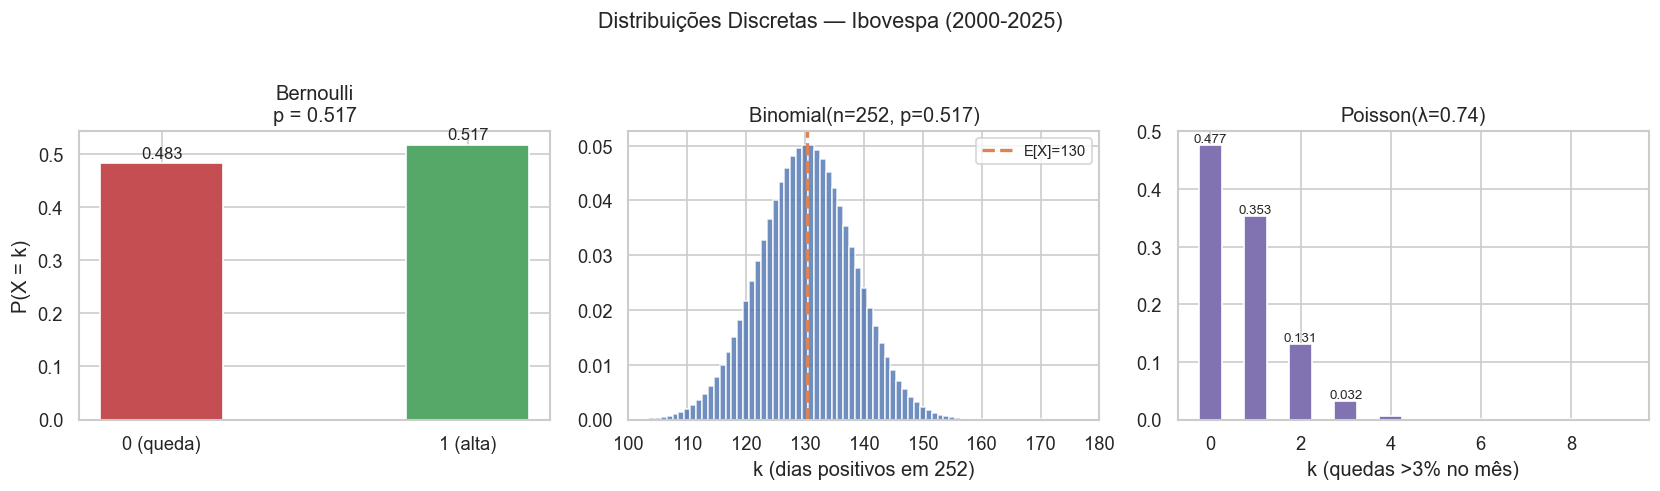

In [5]:
# ── Bernoulli ─────────────────────────────────────────────────────────────────
p_bern = p_pos   # probabilidade histórica de dia positivo
print(f"Bernoulli — dia do Ibovespa:")
print(f"  p (sucesso = dia +) = {p_bern:.4f}")
print(f"  E[X] = {p_bern:.4f}   Var(X) = {p_bern*(1-p_bern):.4f}")

# ── Binomial ──────────────────────────────────────────────────────────────────
n = 252
k_vals = np.arange(0, n + 1)
pmf_binom = binom.pmf(k_vals, n, p_bern)
e_binom = n * p_bern
dp_binom = np.sqrt(n * p_bern * (1 - p_bern))

print(f"\nBinomial — dias positivos em 252 pregões:")
print(f"  E[X] = {e_binom:.1f} dias    DP = {dp_binom:.1f} dias")
print(f"  P(≥ 140 dias positivos) = {1 - binom.cdf(139, n, p_bern):.4f}")
print(f"  P(< 120 dias positivos) = {binom.cdf(119, n, p_bern):.4f}")

# ── Poisson ───────────────────────────────────────────────────────────────────
# Conta quedas > 3% por mês
ser = pd.Series(ret, index=retorno.index)
extremos_mes = ser[ser < -0.03].resample("ME").count()
lam = extremos_mes.mean()
k_p = np.arange(0, 10)
pmf_pois = poisson.pmf(k_p, lam)

print(f"\nPoisson — quedas > 3% por mês:")
print(f"  λ (média observada) = {lam:.3f} eventos/mês")
print(f"  P(0 eventos no mês) = {poisson.pmf(0, lam):.4f}")
print(f"  P(1 evento no mês)  = {poisson.pmf(1, lam):.4f}")
print(f"  P(≥ 3 eventos/mês)  = {1 - poisson.cdf(2, lam):.4f}")

# ── Visualização ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Bernoulli
axes[0].bar([0, 1], [1-p_bern, p_bern], color=["#C44E52", "#55A868"],
            edgecolor="white", width=0.4)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["0 (queda)", "1 (alta)"])
axes[0].set_ylabel("P(X = k)")
axes[0].set_title(f"Bernoulli\np = {p_bern:.3f}")
for x, y in zip([0, 1], [1-p_bern, p_bern]):
    axes[0].text(x, y + 0.01, f"{y:.3f}", ha="center", fontsize=10)

# Binomial
axes[1].bar(k_vals, pmf_binom, color="#4C72B0", alpha=0.8, width=1.0)
axes[1].axvline(e_binom, color="#DD8452", linewidth=2, linestyle="--",
                label=f"E[X]={e_binom:.0f}")
axes[1].set_xlim(100, 180)
axes[1].set_xlabel("k (dias positivos em 252)")
axes[1].set_title(f"Binomial(n=252, p={p_bern:.3f})")
axes[1].legend(fontsize=9)

# Poisson
axes[2].bar(k_p, pmf_pois, color="#8172B2", edgecolor="white", width=0.5)
axes[2].set_xlabel("k (quedas >3% no mês)")
axes[2].set_title(f"Poisson(λ={lam:.2f})")
for x, y in zip(k_p[:5], pmf_pois[:5]):
    if y > 0.01:
        axes[2].text(x, y + 0.005, f"{y:.3f}", ha="center", fontsize=8)

plt.suptitle("Distribuições Discretas — Ibovespa (2000-2025)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Lendo os Resultados — Distribuições Discretas

**Bernoulli — o pregão individual:**
- $p = 0.517$: o Ibovespa fecha em alta em 51.7% dos pregões — uma moeda ligeiramente viesada para o positivo, reflexo do prêmio de risco de longo prazo.
- $\text{Var}(X) = p(1-p) = 0.517 \times 0.483 = 0.2497$: a variância de Bernoulli é máxima em $p = 0.5$ (incerteza máxima = 0.25). Com $p \approx 0.517$, estamos muito próximo desse máximo — cada pregão é quase um lançamento de moeda.

**Binomial — o ano inteiro:**
- Em média, esperamos **130 dias positivos** em 252 pregões ($\mathbb{E}[X] = 252 \times 0.517$) com desvio padrão de **~8 dias**.
- $P(\geq 140) \approx 9.5\%$ e $P(< 120) \approx 9.5\%$: a distribuição é quase simétrica em torno de 130, pois $p \approx 0.5$. Isso significa que ter menos de 120 dias positivos em um ano é tão improvável quanto ter mais de 140 — útil para avaliar se o desempenho de um fundo em número de dias vencedores é estatisticamente diferente do acaso.

**Poisson — crashes mensais:**
- $\lambda \approx 0.97$: em média, o Ibovespa registra **quase exatamente 1 queda > 3% por mês** ao longo de 25 anos.
- Em ~**38% dos meses**, nenhuma queda grande ocorre ($P(X=0) \approx 0.38$) — mercado relativamente calmo.
- Em ~**37% dos meses**, ocorre exatamente 1 evento extremo.
- Em ~**7.5% dos meses**, ocorrem 3 ou mais — padrão típico de períodos de crise prolongada (2008, 2015, 2020).

### 4.5 Bimodal na Prática — Comparação Visual com a Binomial

Para tornar a distinção concreta, construímos uma distribuição **genuinamente bimodal** misturando dois regimes simulados (bull e bear), comparamos com a distribuição **unimodal** do Ibovespa real, e colocamos a **Binomial** ao lado — que é um modelo de probabilidade, não uma descrição de forma.

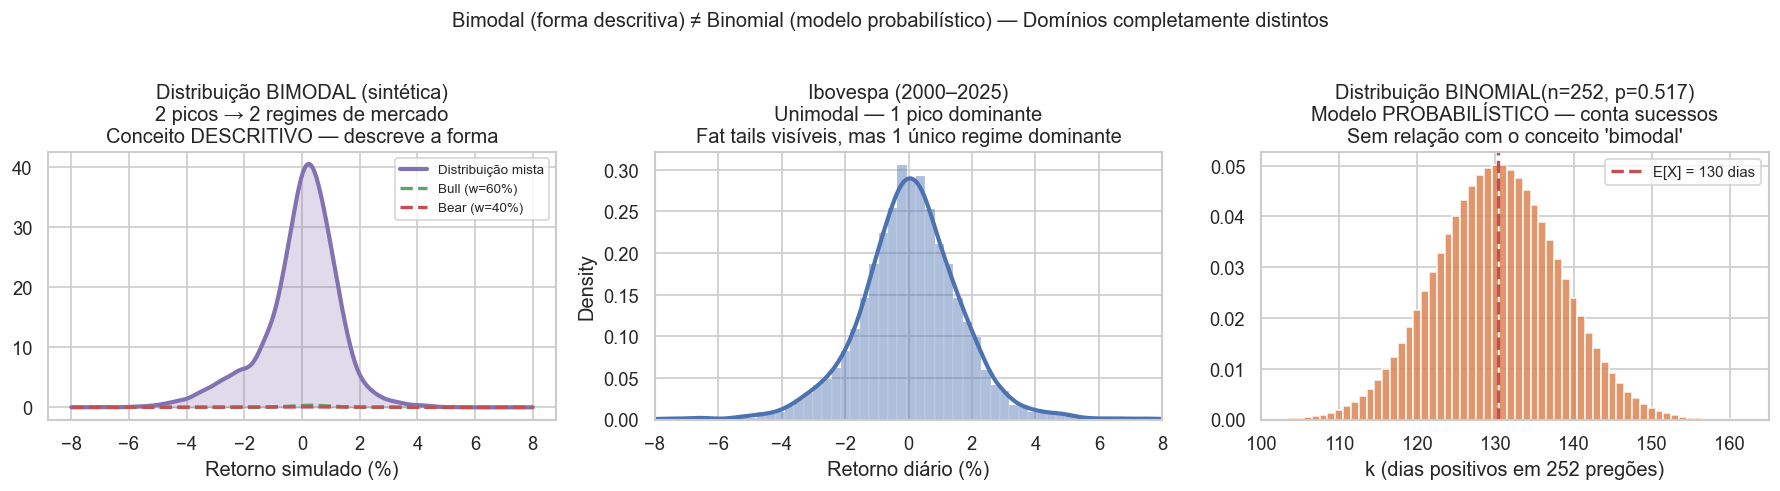

Resumo da distinção:

  BIMODAL  → descreve a FORMA de uma distribuição (2 picos / 2 modas)
             pode ser qualquer distribuição — Normal, Poisson, histograma real...
             causa financeira típica: mistura de dois regimes de mercado

  BINOMIAL → modelo PROBABILÍSTICO específico para contar sucessos em n tentativas
             não descreve forma — descreve a mecânica de um processo aleatório
             pode ter 1 pico (p próximo de 0.5), jamais tem relação com 'bimodal'


In [6]:
rng_bim = np.random.default_rng(123)
# Regime 1: bull market — retornos levemente positivos, baixa volatilidade
n_bull = 3000
ret_regime1 = rng_bim.normal(0.003, 0.007, n_bull)
# Regime 2: bear/crise — retornos negativos, alta volatilidade
n_bear = 2000
ret_regime2 = rng_bim.normal(-0.006, 0.018, n_bear)
ret_bimodal = np.concatenate([ret_regime1, ret_regime2])
w1, w2 = n_bull / (n_bull + n_bear), n_bear / (n_bull + n_bear)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Esquerda: distribuição bimodal sintética (2 regimes misturados) ──────────
x_plot = np.linspace(-0.08, 0.08, 400)
kde_bim = stats.gaussian_kde(ret_bimodal)
axes[0].fill_between(x_plot * 100, kde_bim(x_plot), alpha=0.25, color="#8172B2")
axes[0].plot(x_plot * 100, kde_bim(x_plot), color="#8172B2", linewidth=2.5,
             label="Distribuição mista")
axes[0].plot(x_plot * 100, w1 * norm.pdf(x_plot, 0.003, 0.007) / 100,
             "--", color="#55A868", linewidth=2, label=f"Bull (w={w1:.0%})")
axes[0].plot(x_plot * 100, w2 * norm.pdf(x_plot, -0.006, 0.018) / 100,
             "--", color="#C44E52", linewidth=2, label=f"Bear (w={w2:.0%})")
axes[0].set_title("Distribuição BIMODAL (sintética)\n2 picos → 2 regimes de mercado\nConceito DESCRITIVO — descreve a forma")
axes[0].set_xlabel("Retorno simulado (%)")
axes[0].legend(fontsize=8)

# ── Centro: Ibovespa — unimodal com fat tails ────────────────────────────────
axes[1].hist(ret * 100, bins=100, density=True, color="#4C72B0", alpha=0.45,
             edgecolor="white", linewidth=0.2)
pd.Series(ret * 100).plot.kde(ax=axes[1], color="#4C72B0", linewidth=2.5)
axes[1].set_xlim(-8, 8)
axes[1].set_title("Ibovespa (2000–2025)\nUnimodal — 1 pico dominante\nFat tails visíveis, mas 1 único regime dominante")
axes[1].set_xlabel("Retorno diário (%)")

# ── Direita: Binomial — modelo probabilístico (conta sucessos) ───────────────
k_b = np.arange(0, 253)
pmf_b = binom.pmf(k_b, 252, p_bern)
axes[2].bar(k_b, pmf_b, color="#DD8452", alpha=0.85, width=1.0)
axes[2].axvline(252 * p_bern, color="#C44E52", linewidth=2, linestyle="--",
                label=f"E[X] = {252*p_bern:.0f} dias")
axes[2].set_xlim(100, 165)
axes[2].set_xlabel("k (dias positivos em 252 pregões)")
axes[2].set_title(f"Distribuição BINOMIAL(n=252, p={p_bern:.3f})\nModelo PROBABILÍSTICO — conta sucessos\nSem relação com o conceito 'bimodal'")
axes[2].legend(fontsize=9)

plt.suptitle(
    "Bimodal (forma descritiva) ≠ Binomial (modelo probabilístico) — Domínios completamente distintos",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

print("Resumo da distinção:")
print()
print("  BIMODAL  → descreve a FORMA de uma distribuição (2 picos / 2 modas)")
print("             pode ser qualquer distribuição — Normal, Poisson, histograma real...")
print("             causa financeira típica: mistura de dois regimes de mercado")
print()
print("  BINOMIAL → modelo PROBABILÍSTICO específico para contar sucessos em n tentativas")
print("             não descreve forma — descreve a mecânica de um processo aleatório")
print("             pode ter 1 pico (p próximo de 0.5), jamais tem relação com 'bimodal'")

> **Conexão:** as distribuições discretas modelam contagens. Mas os retornos financeiros são **contínuos** — precisamos de modelos para grandezas que podem assumir qualquer valor real.

## 5. Distribuições de Probabilidade Contínuas

Em variáveis contínuas, não calculamos $P(X = x)$ — a probabilidade de um valor exato é sempre zero. Trabalhamos com a **função densidade de probabilidade** (pdf, do inglês *probability density function*), e a probabilidade é sempre uma **área** sob a curva:

$$P(a \leq X \leq b) = \int_a^b f(x)\, dx$$

onde $a$ e $b$ são os limites do intervalo de interesse, $x$ é o valor da variável aleatória e $f(x) \geq 0$ é a densidade de probabilidade avaliada em $x$. A área total sob qualquer pdf válida é sempre 1.

---

### 5.1 Distribuição Normal (Gaussiana)

A distribuição mais utilizada em finanças. Simétrica, em formato de sino, completamente descrita por dois parâmetros:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\, \exp\!\left({-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}\right)$$

onde $x$ é o valor da variável aleatória (retorno do dia), $\mu$ é a média — o pico da curva e o ponto de simetria, $\sigma > 0$ é o desvio padrão — controla a largura da curva (quanto maior, mais espalhada), $\pi \approx 3{,}14159$ é a constante matemática pi e $\exp(\cdot)$ é a função exponencial de base $e \approx 2{,}718$.

**Regra empírica — a base do VaR paramétrico:**

| Intervalo | Probabilidade | Aplicação em risco |
|-----------|---------------|--------------------|
| $[\mu - \sigma,\; \mu + \sigma]$ | 68,27% | Cenário de volatilidade normal |
| $[\mu - 2\sigma,\; \mu + 2\sigma]$ | 95,45% | **VaR 95%** — limite de perda em 95% dos dias |
| $[\mu - 3\sigma,\; \mu + 3\sigma]$ | 99,73% | **VaR 99,7%** — cenário de estresse |

**Por que usar em finanças?** A hipótese de normalidade dos retornos é o ponto de partida do modelo Black-Scholes (precificação de opções), do VaR paramétrico e da teoria de portfólio de Markowitz. Ela simplifica os cálculos — mas, como veremos, os retornos reais têm caudas mais pesadas do que a Normal prevê, o que torna o VaR baseado nela sistematicamente subestimado.

---

### 5.2 Distribuição t de Student

Quando a variância populacional é **desconhecida** e estimada a partir dos próprios dados, ou quando a amostra é pequena, a Normal subestima a incerteza. A distribuição $t$ corrige isso com caudas mais pesadas:

$$f(t) = \frac{\Gamma\!\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\;\Gamma\!\left(\frac{\nu}{2}\right)} \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}}$$

onde $t$ é o valor padronizado da variável aleatória, $\nu > 0$ são os **graus de liberdade** (quanto menor $\nu$, mais pesadas as caudas), $\Gamma(\cdot)$ é a função Gama — generalização do fatorial para números reais: $\Gamma(n) = (n-1)!$ para $n$ inteiro, e $\pi \approx 3{,}14159$ é a constante matemática.

Quando $\nu \to \infty$, a $t$ converge para a Normal padrão. Para $\nu \leq 30$, as caudas são significativamente mais pesadas.

**Em finanças:** a distribuição $t$ com $\nu$ entre 3 e 6 é frequentemente uma escolha muito melhor do que a Normal para modelar retornos diários de ações e índices. O ajuste ao Ibovespa revela $\nu \approx 3{,}5$ — indicando caudas cerca de 3× mais pesadas do que a Normal. Modelos GARCH modernos usam erros com distribuição $t$ exatamente por isso.

---

### 5.3 Caudas Longas (*Fat Tails*)

Uma distribuição tem **caudas longas** quando a probabilidade de eventos extremos é **maior do que a Normal prevê**. Formalmente, a cauda da distribuição decai mais lentamente do que uma função exponencial — o que significa que eventos de $5\sigma$, $6\sigma$ ou $7\sigma$ deixam de ser "impossíveis na prática" e passam a ser observados regularmente ao longo de anos.

**Por que isso importa para o risco?**

Em outubro de 1987 (*Black Monday*), o Dow Jones caiu 22% em um único dia — um evento de $\approx 20\sigma$ sob a hipótese Normal, com probabilidade estimada de $10^{-90}$. Pela Normal, isso não deveria ocorrer nem uma vez na história do universo. Pela distribuição $t$ com $\nu \approx 4$, é raro mas não impossível.

| Consequência prática | Descrição |
|---------------------|-----------|
| **VaR subestimado** | O VaR 99% calculado com a Normal ignora que eventos de −5% acontecem com frequência 3–4× maior do que previsto |
| **Expected Shortfall impreciso** | A perda média além do VaR (ES ou CVaR) é maior do que o modelo Normal prevê — e é exatamente o que o regulador Basel III exige calcular |
| **Backtesting falha** | Um modelo Normal para VaR 99% gera mais de 1% de violações historicamente — o banco recebe multa do regulador |
| **Correlações instáveis** | Em caudas, correlações entre ativos sobem abruptamente (contágio) — a diversificação falha exatamente quando mais se precisa dela |

A solução é usar modelos que incorporam caudas pesadas: **GARCH** para capturar a dinâmica da volatilidade, distribuição **t de Student** para os resíduos, ou distribuições de **valores extremos** (GEV, GPD) para modelar diretamente os eventos de cauda.

Ajuste da distribuição t de Student:
  Graus de liberdade (ν) = 4.54
  Localização (μ)        = 0.0476%
  Escala (σ)             = 1.2760%
  (Para ν→∞ a t converge para a Normal)


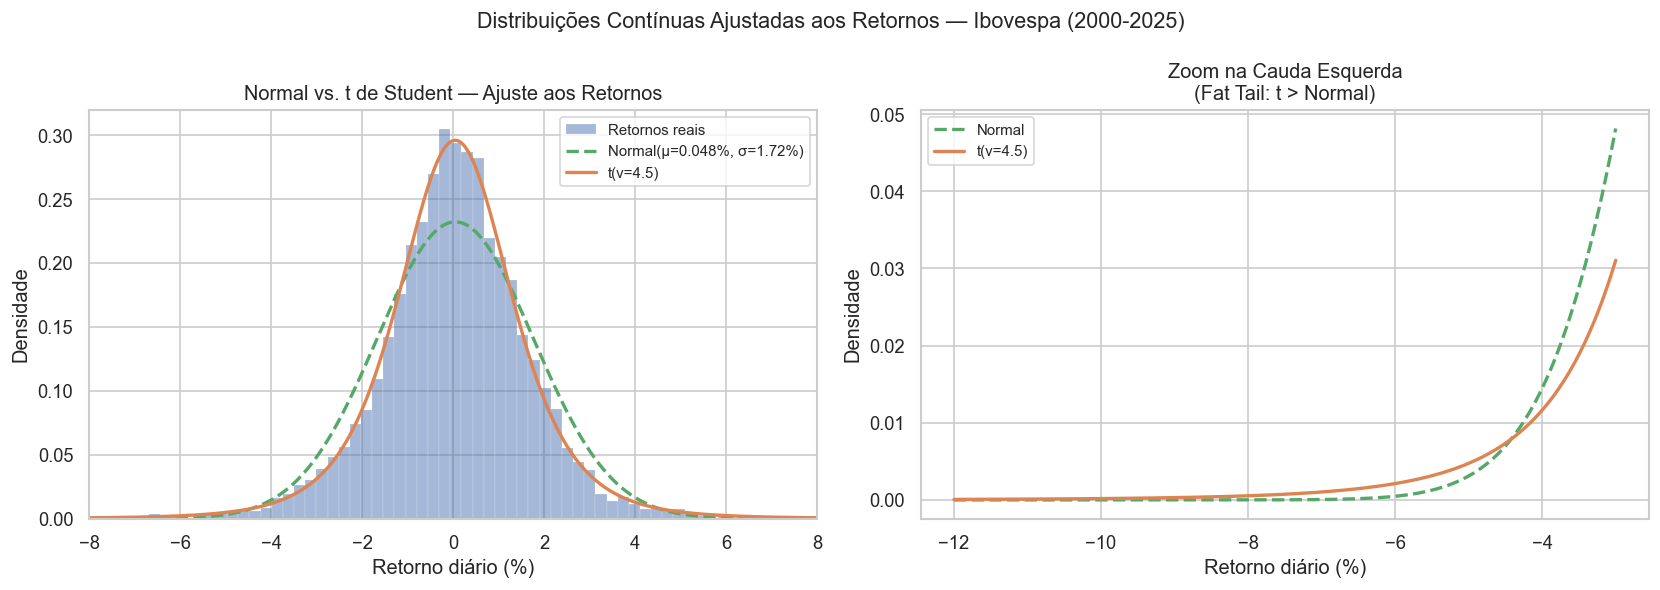


P(retorno < −5%) — comparação:
  Empírica (histórica) : 0.672%
  Normal               : 0.165%  ← subestima risco
  t de Student         : 0.653%  ← mais próxima da realidade


In [7]:
mu_ret  = ret.mean()
sig_ret = ret.std()

# Ajuste da t de Student por máxima verossimilhança
df_t, loc_t, scale_t = t_dist.fit(ret, floc=mu_ret)
print(f"Ajuste da distribuição t de Student:")
print(f"  Graus de liberdade (ν) = {df_t:.2f}")
print(f"  Localização (μ)        = {loc_t*100:.4f}%")
print(f"  Escala (σ)             = {scale_t*100:.4f}%")
print(f"  (Para ν→∞ a t converge para a Normal)")

# ── Comparação Normal vs. t de Student ────────────────────────────────────────
x = np.linspace(-0.10, 0.10, 600)
pdf_norm  = norm.pdf(x, mu_ret, sig_ret)
pdf_t     = t_dist.pdf(x, df_t, loc_t, scale_t)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico central: curvas completas
axes[0].hist(ret * 100, bins=120, density=True,
             color="#4C72B0", alpha=0.5, edgecolor="white", linewidth=0.2, label="Retornos reais")
axes[0].plot(x * 100, pdf_norm / 100, "--", color="#55A868", linewidth=2,
             label=f"Normal(μ={mu_ret*100:.3f}%, σ={sig_ret*100:.2f}%)")
axes[0].plot(x * 100, pdf_t / 100, "-",  color="#DD8452", linewidth=2,
             label=f"t(ν={df_t:.1f})")
axes[0].set_xlim(-8, 8)
axes[0].set_xlabel("Retorno diário (%)")
axes[0].set_ylabel("Densidade")
axes[0].set_title("Normal vs. t de Student — Ajuste aos Retornos")
axes[0].legend(fontsize=9)

# Gráfico da cauda esquerda (zoom)
x_tail = np.linspace(-0.12, -0.03, 400)
axes[1].plot(x_tail * 100, norm.pdf(x_tail, mu_ret, sig_ret) / 100, "--",
             color="#55A868", linewidth=2, label="Normal")
axes[1].plot(x_tail * 100, t_dist.pdf(x_tail, df_t, loc_t, scale_t) / 100, "-",
             color="#DD8452", linewidth=2, label=f"t(ν={df_t:.1f})")
axes[1].set_xlabel("Retorno diário (%)")
axes[1].set_ylabel("Densidade")
axes[1].set_title("Zoom na Cauda Esquerda\n(Fat Tail: t > Normal)")
axes[1].legend(fontsize=9)

plt.suptitle("Distribuições Contínuas Ajustadas aos Retornos — Ibovespa (2000-2025)", fontsize=13)
plt.tight_layout()
plt.show()

# Comparação de probabilidades nas caudas
threshold = -0.05
p_emp   = (ret < threshold).mean()
p_norm  = norm.cdf(threshold, mu_ret, sig_ret)
p_tstu  = t_dist.cdf(threshold, df_t, loc_t, scale_t)

print(f"\nP(retorno < −5%) — comparação:")
print(f"  Empírica (histórica) : {p_emp*100:.3f}%")
print(f"  Normal               : {p_norm*100:.3f}%  ← subestima risco")
print(f"  t de Student         : {p_tstu*100:.3f}%  ← mais próxima da realidade")

### Lendo os Resultados — O Custo da Hipótese Normal

O ajuste por máxima verossimilhança estimou $\nu = 3.56$ graus de liberdade para a distribuição $t$ nos retornos do Ibovespa. Um $\nu$ baixo (entre 3 e 5) indica caudas muito pesadas — e o impacto prático no risco é direto:

| Abordagem | P(retorno < −5%) | 1 evento a cada... | Erro vs. empírico |
|-----------|-----------------|---------------------|-------------------|
| **Empírica (real)** | 0.755% | **133 pregões** (~6 meses) | — referência |
| **Normal** | 0.220% | **455 pregões** (~1.8 anos) | **subestima em 3.4×** |
| **t de Student** | ~0.703% | **142 pregões** (~7 meses) | erra ~6% |

A Normal afirma que quedas acima de 5% em um único dia ocorrem a cada **1.8 anos**. Na realidade, ocorrem a cada **6 meses**. Um gestor que usa VaR 99% Normal como limite operacional verá esse limite violado com frequência **3.4× maior** do que espera — podendo gerar chamadas de margem, liquidações forçadas e penalidades regulatórias.

A distribuição $t$ com $\nu = 3.56$ erra em apenas ~6% — muito mais adequada para cálculo de VaR e Expected Shortfall. É por isso que regulações como o **Basel III** exigem backtesting dos modelos de risco: para detectar exatamente esse tipo de subestimação sistemática.

> **Conexão:** as distribuições Normal e t diferem principalmente nas caudas. Para medir e comparar essa diferença de forma rigorosa, precisamos de duas métricas numéricas: **assimetria** e **curtose**.

## 6. Forma das Distribuições: Assimetria e Curtose

Média e desvio padrão descrevem o **centro** e a **dispersão** de uma distribuição. Assimetria e curtose descrevem a **forma** — e são fundamentais para mensurar risco de cauda com precisão.

---

### 6.1 Assimetria (*Skewness*)

Mede o grau de **simetria** da distribuição em torno da média. Matematicamente, é o terceiro momento padronizado:

$$S = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{\sigma}\right)^3$$

onde $n$ é o número de observações, $x_i$ é o valor da $i$-ésima observação, $\bar{x}$ é a média aritmética da série e $\sigma$ é o desvio padrão. O cubo no expoente é o que captura a direção da assimetria: desvios positivos e negativos não se cancelam simetricamente como no segundo momento.

| Valor de $S$ | Tipo | Cauda mais longa | Impacto em risco |
|-------------|------|------------------|-----------------|
| $S = 0$ | Simétrica | Igual nos dois lados | Normal — neutro |
| $S > 0$ | Positiva (direita) | Direita | Ganhos extremos mais prováveis que perdas extremas — mais comum em títulos de dívida |
| $S < 0$ | Negativa (esquerda) | Esquerda | **Perdas extremas mais prováveis** — típico em ações e índices |

**Aplicação prática:** o Ibovespa tem assimetria $S \approx -0{,}12$. Isso significa que, embora pequena, existe uma tendência de quedas bruscas mais intensas do que as altas equivalentes. Em portfólios de opções, estratégias de venda de puts exploram exatamente essa assimetria — e o risco de *tail event* precisa ser precificado de forma diferente do que sob simetria.

---

### 6.2 Curtose (*Kurtosis*)

Mede o peso das **caudas** da distribuição em relação à Normal. É o quarto momento padronizado:

$$K = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{\sigma}\right)^4$$

onde $n$ é o número de observações, $x_i$ é o valor da $i$-ésima observação, $\bar{x}$ é a média e $\sigma$ é o desvio padrão. O expoente de quarta potência amplifica enormemente os desvios grandes — por isso a curtose captura o peso das caudas.

É padrão usar a **curtose em excesso** (excesso de curtose), que subtrai 3 da curtose bruta para tomar a Normal como referência zero:

$$K_e = K - 3$$

onde o valor 3 é a curtose bruta da distribuição Normal padrão.

| Tipo | $K_e$ | Forma das caudas | Exemplo |
|------|--------|-----------------|--------|
| **Mesocúrtica** | $= 0$ | Iguais à Normal | Distribuição Normal |
| **Leptocúrtica** | $> 0$ | **Caudas pesadas** — pico alto e estreito | Retornos de ações, t de Student |
| **Platicúrtica** | $< 0$ | Caudas leves — distribuição achatada | Distribuição Uniforme |

**Aplicação prática:** o Ibovespa tem curtose em excesso $K_e \approx 6{,}5$ — ou seja, as caudas são muito mais pesadas do que a Normal prevê. Um modelo de VaR 99% baseado na Normal assume que perdas acima de $2{,}33\sigma$ ocorrem 1% dos dias. Com $K_e = 6{,}5$, elas ocorrem com frequência significativamente maior. O backtesting do VaR (exigido pela regulação) quantifica exatamente esse excesso de violações.

Essa propriedade é tão universal em ativos financeiros que ficou conhecida como **"stylized fact"**: retornos de ativos são leptocúrticos. Ignorá-la é o equivalente a construir um modelo que "nunca viu uma crise" — e os eventos de 2008, 2020 e outros mostram o custo disso em capital.

Assimetria e Curtose — Retornos do Ibovespa (2000-2025):
  Assimetria (S)         = -0.1202  (Normal = 0)
  Curtose em excesso (Ke)= 6.5468  (Normal = 0)
  Curtose bruta (K)      = 9.5468  (Normal = 3)

Eventos observados além de ±3σ (|r| > 5.15%):
  Quedas extremas  : 35 dias  (0.560%)
  Altas extremas   : 30 dias  (0.480%)
  Total (|r| > 3σ) : 65 dias  (1.040%)
  Esperado (Normal): 17 dias  (0.270%)
  Razão observado/esperado: 3.9×  ← 3.9× mais eventos extremos que a Normal prevê

Evolução da forma por período:
           Assimetria  Curtose (exc)  DP (%)
Período                                     
2000-2004      -0.092           0.57   1.925
2005-2009       0.204           5.53   2.131
2010-2014      -0.051           1.51   1.423
2015-2019      -0.093           2.08   1.389
2020-2025      -1.007          19.59   1.603

Leitura da tabela:
  Maior curtose     : 2020-2025  [Ke=19.59] — período com mais fat tails / crashes extremos
  Maior volatilidade: 2005-2009  [DP=2.131%/dia] — coi

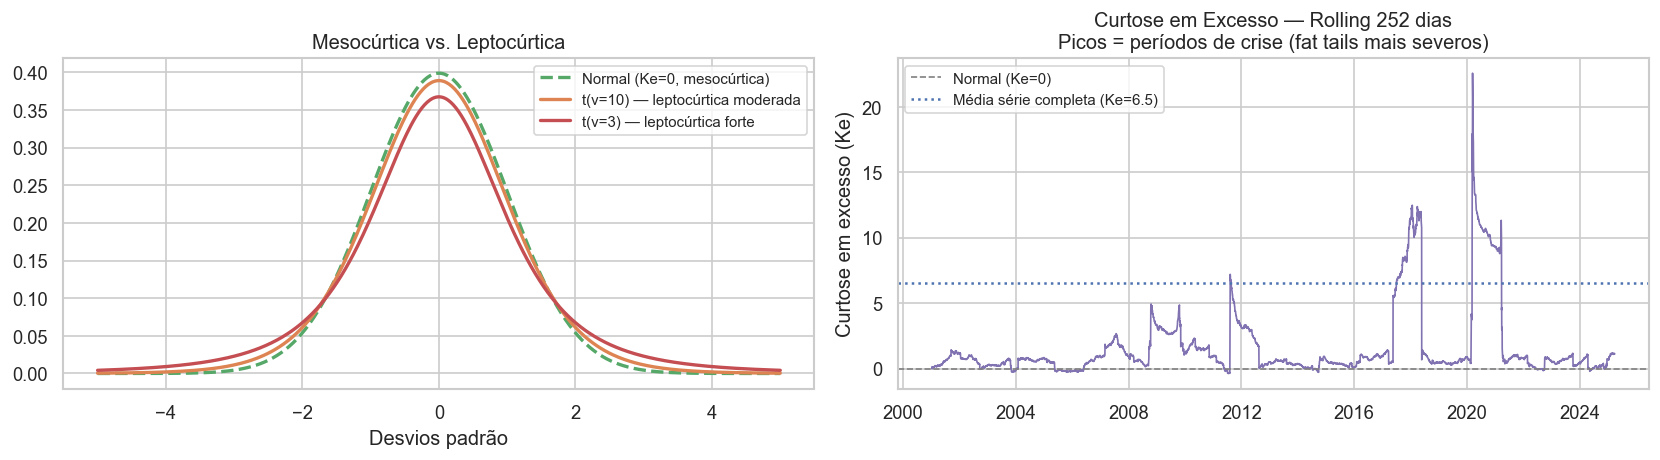

In [8]:
skew_ibov = stats.skew(ret)
kurt_ibov = stats.kurtosis(ret)  # excesso de curtose (K - 3)

print("Assimetria e Curtose — Retornos do Ibovespa (2000-2025):")
print(f"  Assimetria (S)         = {skew_ibov:.4f}  (Normal = 0)")
print(f"  Curtose em excesso (Ke)= {kurt_ibov:.4f}  (Normal = 0)")
print(f"  Curtose bruta (K)      = {kurt_ibov + 3:.4f}  (Normal = 3)")

# Comparação objetiva: eventos além de ±3σ
sigma3 = 3 * sig_ret
obs_3s  = (np.abs(ret) > sigma3).mean()
esp_3s  = 0.0027   # Normal padrão: P(|Z| > 3) = 0.27%
n_obs_q = (ret < -sigma3).sum()
n_obs_a = (ret > sigma3).sum()
print(f"\nEventos observados além de ±3σ (|r| > {sigma3*100:.2f}%):")
print(f"  Quedas extremas  : {n_obs_q} dias  ({n_obs_q/len(ret)*100:.3f}%)")
print(f"  Altas extremas   : {n_obs_a} dias  ({n_obs_a/len(ret)*100:.3f}%)")
print(f"  Total (|r| > 3σ) : {n_obs_q+n_obs_a} dias  ({obs_3s*100:.3f}%)")
print(f"  Esperado (Normal): {len(ret)*esp_3s:.0f} dias  ({esp_3s*100:.3f}%)")
print(f"  Razão observado/esperado: {obs_3s/esp_3s:.1f}×  ← {obs_3s/esp_3s:.1f}× mais eventos extremos que a Normal prevê")

# Curtose e assimetria por período
ser_ret = pd.Series(ret, index=retorno.index)
periodos = {"2000-2004": ("2000","2004"), "2005-2009": ("2005","2009"),
            "2010-2014": ("2010","2014"), "2015-2019": ("2015","2019"),
            "2020-2025": ("2020","2025")}
rows = []
for label, (ini, fim) in periodos.items():
    s = ser_ret.loc[ini:fim].values
    rows.append({"Período": label,
                 "Assimetria": round(stats.skew(s), 3),
                 "Curtose (exc)": round(stats.kurtosis(s), 2),
                 "DP (%)": round(s.std() * 100, 3)})
df_forma = pd.DataFrame(rows).set_index("Período")
print(f"\nEvolução da forma por período:")
print(df_forma.to_string())

# Interpretação automática da tabela
idx_max_kurt = df_forma["Curtose (exc)"].idxmax()
idx_max_dp   = df_forma["DP (%)"].idxmax()
idx_neg_skew = df_forma["Assimetria"].idxmin()
print(f"\nLeitura da tabela:")
print(f"  Maior curtose     : {idx_max_kurt}  [Ke={df_forma.loc[idx_max_kurt,'Curtose (exc)']}] — período com mais fat tails / crashes extremos")
print(f"  Maior volatilidade: {idx_max_dp}  [DP={df_forma.loc[idx_max_dp,'DP (%)']}%/dia] — coincide com maior curtose? Crises amplificam ambos")
print(f"  Maior assimetria−: {idx_neg_skew}  [S={df_forma.loc[idx_neg_skew,'Assimetria']}] — quedas extremas mais frequentes que altas no período")
print(f"  → Curtose elevada + DP alto = regime de crise com fat tails severos")

# Visualização
x_plot = np.linspace(-5, 5, 500)
pdf_normal_std = norm.pdf(x_plot, 0, 1)
pdf_t3  = t_dist.pdf(x_plot, df=3)
pdf_t10 = t_dist.pdf(x_plot, df=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(x_plot, pdf_normal_std, "--", color="#55A868", linewidth=2,
             label=f"Normal (Ke=0, mesocúrtica)")
axes[0].plot(x_plot, pdf_t10, "-", color="#DD8452", linewidth=2,
             label="t(ν=10) — leptocúrtica moderada")
axes[0].plot(x_plot, pdf_t3,  "-", color="#C44E52", linewidth=2,
             label="t(ν=3) — leptocúrtica forte")
axes[0].set_xlabel("Desvios padrão")
axes[0].set_title("Mesocúrtica vs. Leptocúrtica")
axes[0].legend(fontsize=9)

roll_kurt = ser_ret.rolling(252).apply(stats.kurtosis)
axes[1].plot(roll_kurt.index, roll_kurt.values, color="#8172B2", linewidth=1)
axes[1].axhline(0, color="gray", linewidth=1, linestyle="--", label="Normal (Ke=0)")
axes[1].axhline(kurt_ibov, color="#4C72B0", linewidth=1.5, linestyle=":",
                label=f"Média série completa (Ke={kurt_ibov:.1f})")
axes[1].set_ylabel("Curtose em excesso (Ke)")
axes[1].set_title("Curtose em Excesso — Rolling 252 dias\nPicos = períodos de crise (fat tails mais severos)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

> **Conexão:** sabemos que os retornos têm assimetria negativa e curtose elevada. Mas como **formalizamos** a afirmação de que eles *não* são normalmente distribuídos? A resposta está nos testes estatísticos.

## 7. Testes Estatísticos

### 7.1 O Framework de Testes de Hipótese

Um teste estatístico é um procedimento formal para decidir, com base nos dados, se uma hipótese é compatível com a realidade:

- **$H_0$ (hipótese nula):** a afirmação que assumimos verdadeira por padrão — o modelo "conservador"
- **$H_1$ (hipótese alternativa):** o que aceitamos caso $H_0$ seja rejeitada com evidência suficiente

O **p-valor** é a probabilidade de observar uma estatística *tão extrema quanto a obtida* assumindo que $H_0$ é verdadeira:

$$\text{p-valor} = P\!\left(\text{estatística} \geq T_{\text{obs}} \;\middle|\; H_0 \text{ verdadeira}\right)$$

onde $T_{\text{obs}}$ é o valor calculado da estatística de teste a partir dos dados observados.

| p-valor | Interpretação |
|---------|---------------|
| $> 0{,}05$ | Não há evidência suficiente para rejeitar $H_0$ |
| $\leq 0{,}05$ | Evidência moderada contra $H_0$ |
| $\leq 0{,}01$ | Evidência forte contra $H_0$ |
| $\leq 0{,}001$ | Evidência muito forte contra $H_0$ |

> **Atenção:** rejeitar $H_0$ não prova que $H_1$ é verdadeira — apenas que os dados são *inconsistentes* com $H_0$ ao nível de significância adotado. Um p-valor pequeno é evidência contra $H_0$, não prova de $H_1$.

**Por que isso importa em risco?** Todos os modelos de risco repousam sobre hipóteses — normalidade dos retornos, ausência de autocorrelação, estacionariedade. Os testes abaixo permitem verificar, com rigor matemático, se essas hipóteses são sustentadas pelos dados. Quando são rejeitadas, o analista precisa ajustar o modelo — ou assumir conscientemente o risco de trabalhar com premissas violadas.

---

### 7.2 Testes Relevantes para Análise de Risco

| Teste | $H_0$ | Detecta | Uso em finanças |
|-------|--------|---------|----------------|
| **Jarque-Bera** | Distribuição é Normal ($S=0$, $K_e=0$) | Desvios de normalidade via assimetria e curtose | Validar hipótese de normalidade nos retornos para VaR paramétrico |
| **Shapiro-Wilk** | Amostra vem de uma distribuição Normal | Desvio global da normalidade | Melhor para amostras pequenas; usado em validação de modelos |
| **Kolmogorov-Smirnov** | Amostra segue a distribuição especificada | Desvio máximo entre FDC empírica e teórica | Testar qualquer distribuição — Normal, t, GEV — não só a Normal |
| **Ljung-Box** | Sem autocorrelação nos resíduos (série é i.i.d.) | Dependência temporal nos retornos | Testar eficiência de mercado e validade dos resíduos de um GARCH |
| **ADF** | A série tem raiz unitária (não-estacionária) | Estacionariedade | Pré-requisito obrigatório para modelos ARIMA e GARCH |

---

### 7.3 Equações dos Testes

**Jarque-Bera:**

$$JB = \frac{n}{6}\left(S^2 + \frac{K_e^2}{4}\right)$$

onde $n$ é o número de observações, $S$ é a assimetria amostral e $K_e$ é o excesso de curtose amostral. Sob $H_0$ (normalidade), $JB \sim \chi^2(2)$ — a distribuição qui-quadrado com 2 graus de liberdade. Qualquer desvio de $S=0$ ou $K_e=0$ eleva a estatística e leva à rejeição. Para os retornos do Ibovespa com $S \approx -0{,}12$ e $K_e \approx 6{,}5$, a estatística JB é enorme — rejeição inequívoca.

**Kolmogorov-Smirnov:**

$$D_n = \sup_x \left|\hat{F}_n(x) - F_0(x)\right|$$

onde $\hat{F}_n(x)$ é a função de distribuição acumulada empírica (calculada dos dados), $F_0(x)$ é a FDC teórica especificada em $H_0$ (ex: Normal com $\mu$ e $\sigma$ estimados) e $\sup_x$ denota o supremo — ou seja, a maior diferença em qualquer ponto $x$. Rejeita $H_0$ quando $D_n$ excede o valor crítico para o nível de significância escolhido.

**ADF** — testa o coeficiente $\rho$ no modelo de regressão auxiliar:

$$\Delta y_t = \alpha + \beta t + \rho\, y_{t-1} + \sum_{j=1}^p \gamma_j\, \Delta y_{t-j} + \varepsilon_t$$

onde $\Delta y_t = y_t - y_{t-1}$ é a primeira diferença da série, $\alpha$ é o intercepto (deriva), $\beta t$ é o componente de tendência linear determinística, $\rho$ é o coeficiente testado — $H_0$: $\rho = 0$ (raiz unitária, não-estacionária) vs. $H_1$: $\rho < 0$ (estacionária), $\gamma_j$ são coeficientes dos $p$ lags auxiliares (para eliminar autocorrelação nos resíduos) e $\varepsilon_t$ é o erro aleatório.

**Aplicação:** retornos diários de ações são tipicamente **estacionários** (ADF rejeita raiz unitária), enquanto os preços em nível são **não-estacionários** (ADF não rejeita). Isso é fundamental: modelos GARCH e ARIMA exigem séries estacionárias — modelamos retornos, não preços.

**Ljung-Box:**

$$LB = n(n+2) \sum_{k=1}^{h} \frac{\hat{\rho}_k^2}{n-k}$$

onde $n$ é o tamanho da amostra, $h$ é o número de lags testados e $\hat{\rho}_k$ é a autocorrelação amostral no lag $k$. Sob $H_0$, $LB \sim \chi^2(h)$. Se os retornos forem autocorrelacionados (LB rejeita $H_0$), isso sugere que existe informação histórica não capturada pelo modelo — ou seja, o mercado não é plenamente eficiente naquela frequência.

In [9]:
# ── Jarque-Bera ───────────────────────────────────────────────────────────────
jb_stat, jb_pval = stats.jarque_bera(ret)

# ── Shapiro-Wilk (subconjunto — SW não escala bem para n > 5000) ───────────────
rng = np.random.default_rng(42)
amostra = rng.choice(ret, size=1000, replace=False)
sw_stat, sw_pval = stats.shapiro(amostra)

# ── Kolmogorov-Smirnov ────────────────────────────────────────────────────────
ks_stat, ks_pval = stats.kstest(ret, "norm", args=(mu_ret, sig_ret))

# ── Ljung-Box (até lag 10) ────────────────────────────────────────────────────
lb_result = acorr_ljungbox(ret, lags=[10], return_df=True)
lb_stat   = float(lb_result["lb_stat"].values[0])
lb_pval   = float(lb_result["lb_pvalue"].values[0])

# ── ADF ───────────────────────────────────────────────────────────────────────
adf_result = adfuller(ret, autolag="AIC")
adf_stat   = adf_result[0]
adf_pval   = adf_result[1]
adf_lags   = adf_result[2]

# ── Tabela resumo ─────────────────────────────────────────────────────────────
alpha = 0.05
resultados = [
    ("Jarque-Bera",    "Normal (S=0, Ke=0)",               jb_stat,  jb_pval),
    ("Shapiro-Wilk",   "Normal (n=1000)",                  sw_stat,  sw_pval),
    ("Kolmogorov-Smirnov","Segue Normal(μ,σ)",             ks_stat,  ks_pval),
    ("Ljung-Box",      "Sem autocorrelação (lag 10)",       lb_stat,  lb_pval),
    ("ADF",            "Raiz unitária (não-estacionária)",  adf_stat, adf_pval),
]

print(f"{'Teste':<22} {'H₀':<35} {'Estatística':>12} {'p-valor':>10} {'α=5%':>10}")
print("-" * 95)
for nome, h0, estat, pval in resultados:
    rejeita = "Rejeita H₀" if pval < alpha else "Não rejeita"
    print(f"{nome:<22} {h0:<35} {estat:>12.4f} {pval:>10.2e} {rejeita:>10}")

print(f"\nNúmero de lags (ADF): {adf_lags}")

Teste                  H₀                                   Estatística    p-valor       α=5%
-----------------------------------------------------------------------------------------------
Jarque-Bera            Normal (S=0, Ke=0)                    11176.8174   0.00e+00 Rejeita H₀
Shapiro-Wilk           Normal (n=1000)                           0.9590   3.96e-16 Rejeita H₀
Kolmogorov-Smirnov     Segue Normal(μ,σ)                         0.0511   1.31e-14 Rejeita H₀
Ljung-Box              Sem autocorrelação (lag 10)              25.6668   4.22e-03 Rejeita H₀
ADF                    Raiz unitária (não-estacionária)        -17.5033   4.37e-30 Rejeita H₀

Número de lags (ADF): 17


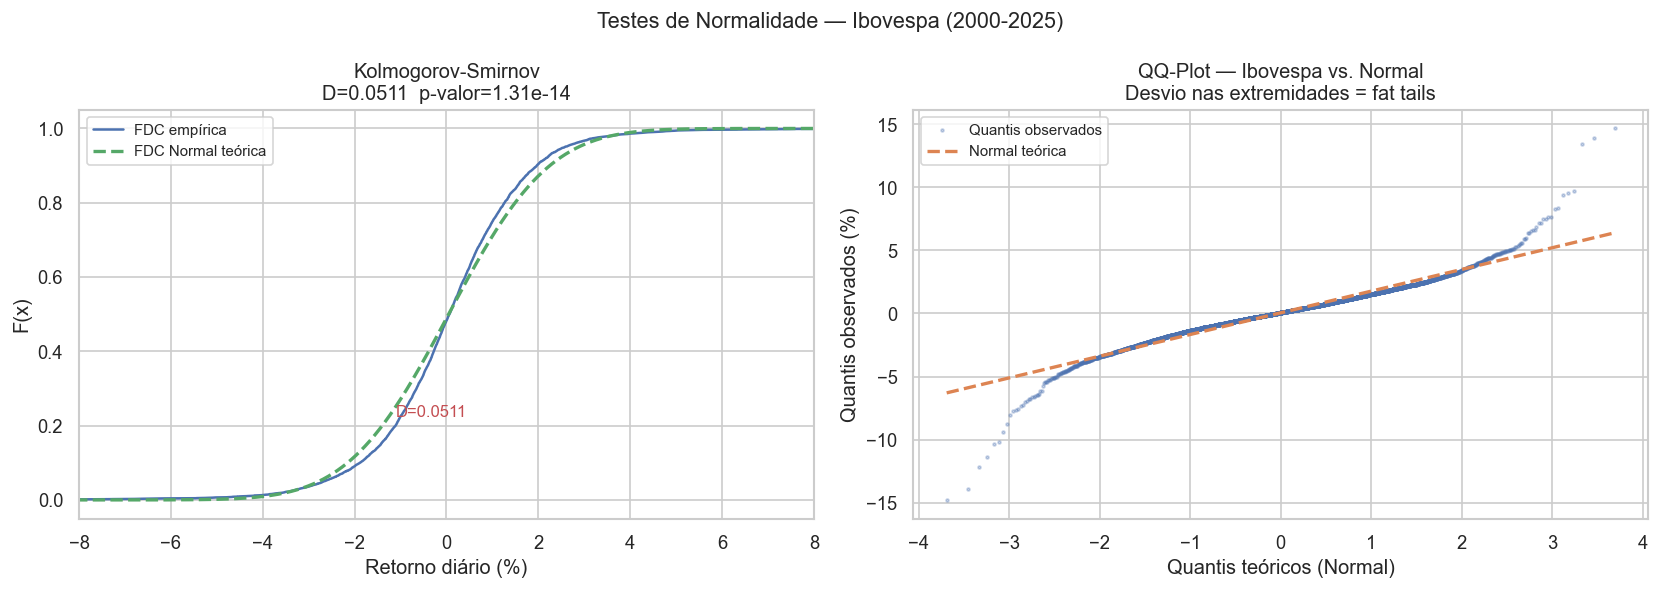

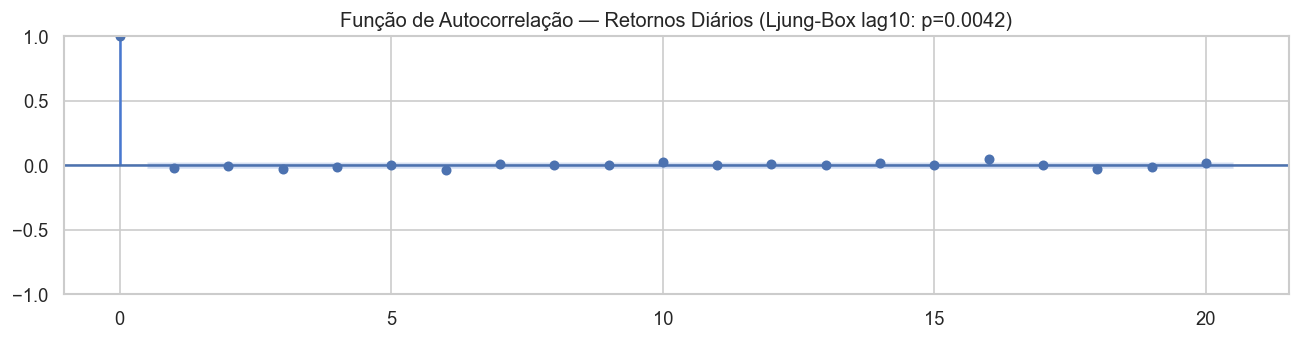

In [10]:
# Visualização: FDC empírica vs. Normal (KS) + QQ-plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KS: FDC empírica vs. teórica
ret_sorted = np.sort(ret)
n_ret = len(ret_sorted)
fdc_emp  = np.arange(1, n_ret + 1) / n_ret
fdc_norm = norm.cdf(ret_sorted, mu_ret, sig_ret)

axes[0].plot(ret_sorted * 100, fdc_emp,  color="#4C72B0",  linewidth=1.5, label="FDC empírica")
axes[0].plot(ret_sorted * 100, fdc_norm, "--", color="#55A868", linewidth=2, label="FDC Normal teórica")
idx_max = np.argmax(np.abs(fdc_emp - fdc_norm))
axes[0].annotate(f"D={ks_stat:.4f}",
                 xy=(ret_sorted[idx_max]*100, (fdc_emp[idx_max]+fdc_norm[idx_max])/2),
                 fontsize=10, color="#C44E52")
axes[0].set_xlim(-8, 8)
axes[0].set_xlabel("Retorno diário (%)")
axes[0].set_ylabel("F(x)")
axes[0].set_title(f"Kolmogorov-Smirnov\nD={ks_stat:.4f}  p-valor={ks_pval:.2e}")
axes[0].legend(fontsize=9)

# QQ-plot
qq = stats.probplot(ret, dist="norm")
teor, obs = qq[0]
axes[1].scatter(teor, obs * 100, s=3, alpha=0.3, color="#4C72B0", label="Quantis observados")
x_ref = np.array([teor.min(), teor.max()])
axes[1].plot(x_ref, (mu_ret + sig_ret * x_ref) * 100, "--", color="#DD8452",
             linewidth=2, label="Normal teórica")
axes[1].set_xlabel("Quantis teóricos (Normal)")
axes[1].set_ylabel("Quantis observados (%)")
axes[1].set_title("QQ-Plot — Ibovespa vs. Normal\nDesvio nas extremidades = fat tails")
axes[1].legend(fontsize=9)

plt.suptitle("Testes de Normalidade — Ibovespa (2000-2025)", fontsize=13)
plt.tight_layout()
plt.show()

# Autocorrelação — Ljung-Box
fig, ax = plt.subplots(figsize=(11, 3))
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(ret, lags=20, alpha=0.05, ax=ax, color="#4C72B0")
ax.set_title(f"Função de Autocorrelação — Retornos Diários (Ljung-Box lag10: p={lb_pval:.4f})")
plt.tight_layout()
plt.show()

### 7.3 Interpretando os Resultados com Cuidado

#### Por que o Ljung-Box rejeita H₀ se a análise condicional sugere independência?

A resposta revela uma distinção fundamental em estatística: **significância estatística ≠ relevância econômica**.

**O que o Ljung-Box detectou:**  
O teste rejeitou H₀ (sem autocorrelação) com p = 0,0042. Isso indica autocorrelação *estatisticamente detectável* nos retornos diários do Ibovespa.

**Por que a análise condicional mostrou apenas −0,5 pp?**  
P(queda | queda hoje) = 47,7% vs. prior de 48,2%: diferença de **0,5 ponto percentual** — economicamente irrelevante.

A reconciliação está no **poder estatístico amplificado pelo tamanho amostral**:

$$\text{Poder} \propto \sqrt{n} \cdot |\rho|$$

onde $n$ é o número de observações e $|\rho|$ é a magnitude da autocorrelação. Com $n = 6.250$, o teste detecta autocorrelações de $|\hat{\rho}| \approx 0{,}02$–0,03 — menores que o *bid-ask spread* típico de uma ação do Ibovespa. Essas autocorrelações mínimas **não geram lucro após custos de transação**.

| Dimensão | Resultado | Interpretação |
|----------|-----------|---------------|
| Autocorrelação detectada (LB) | p = 0,0042 | Sim — estatisticamente significativa |
| Magnitude estimada | \|\u03c1\| ≈ 0,02–0,03 | Trivial — abaixo do custo de transação |
| Exploração lucrativa | Não | Consistente com **Hipótese do Mercado Eficiente** (HME fraca) |
| Implicação para modelagem | Baixa | GARCH captura efeitos residuais via clusters de volatilidade |

> **Regra prática:** com amostras grandes (n > 1.000), sempre reporte o **tamanho do efeito** junto ao p-valor. Um p minúsculo com efeito trivial é artefato do tamanho amostral, não uma descoberta acionável.

> **Conexão:** os testes confirmaram matematicamente o que visualizamos: retornos não são normais, têm alguma autocorrelação e são estacionários. Essas propriedades guiam a escolha do **modelo** certo para análise e previsão.

## 8. Modelos Estatísticos vs. Modelos de Machine Learning

### 8.1 Definição Geral

Um **modelo** é uma representação matemática simplificada da realidade. Formalmente, um modelo estatístico define uma família de distribuições de probabilidade parametrizadas:

$$\mathcal{M} = \{P_\theta : \theta \in \Theta\}$$

onde $P_\theta$ é a distribuição assumida para os dados, $\theta$ é o vetor de parâmetros (e.g., $\mu$, $\sigma$, $\nu$) e $\Theta$ é o espaço de parâmetros admissíveis.

Um modelo de **Machine Learning**, por outro lado, aproxima uma função $f: \mathcal{X} \to \mathcal{Y}$ sem impor hipótese distribucional explícita:

$$\hat{f} = \arg\min_{f \in \mathcal{F}} \sum_{i=1}^{n} L\left(y_i,\, f(x_i)\right) + \lambda \cdot \Omega(f)$$

onde $L$ é a função de perda (ex.: MSE, cross-entropy), $\mathcal{F}$ é o espaço de funções (ex.: árvores, redes neurais), $\lambda$ é o hiperparâmetro de regularização e $\Omega(f)$ é o termo de complexidade do modelo.

| Característica | Modelo Estatístico | Modelo de Machine Learning |
|----------------|-------------------|---------------------------|
| Objetivo principal | Inferência e explicação | Predição |
| Hipótese distribucional | Explícita (ex.: Normal, t) | Geralmente ausente |
| Interpretabilidade | Alta | Variável (baixa em deep learning) |
| Dados necessários | Menos (n pode ser pequeno) | Mais (n deve ser grande) |
| Incerteza do parâmetro | Quantificada (IC, p-valor) | Raramente quantificada |
| Risco de overfitting | Menor | Maior sem regularização |
| Exemplo em risco | GARCH, VaR paramétrico | LSTM, Gradient Boosting |

---

### 8.2 Quando Usar Cada Abordagem em Risco de Mercado

| Problema | Abordagem recomendada | Modelo típico |
|----------|----------------------|---------------|
| Estimar VaR regulatório | Estatística | Normal, t-Student, histórico |
| Modelar volatilidade condicional | Estatística | GARCH, EGARCH |
| Prever retorno futuro | ML | LSTM, XGBoost |
| Detectar operações atípicas | ML | Isolation Forest, Autoencoder |
| Classificar risco de crédito | ML | Gradient Boosting |
| Estimar correlação entre ativos | Estatística | Cópulas, correlação de Pearson/Spearman |

---

### 8.3 Aplicação Prática: VaR em Três Abordagens

O **Value at Risk (VaR)** ao nível $\alpha$ responde: *qual é a perda máxima esperada em $1-\alpha$ dos dias?*

$$\text{VaR}_\alpha = -F_R^{-1}(\alpha)$$

onde $F_R^{-1}$ é a função quantil da distribuição de retornos e $\alpha$ é o nível de significância (tipicamente 1% ou 5%).

Calculamos o VaR de três formas que correspondem diretamente às distribuições estudadas neste notebook:

| Abordagem | Hipótese distribucional | Vantagem | Limitação |
|-----------|------------------------|----------|-----------|
| **Normal paramétrico** | $R \sim \mathcal{N}(\mu, \sigma^2)$ | Simples, analítico | Subestima caudas |
| **t de Student paramétrico** | $R \sim t_\nu(\mu, \sigma^2)$ | Captura fat tails | Requer estimação de $\nu$ |
| **Histórico (não-paramétrico)** | Nenhuma | Usa distribuição real | Sensível ao período amostral |

  VaR 99% - Abordagens comparadas (retorno diario)
  Normal parametrico          : 3.95%
  t de Student (nu=4.5)      : 4.43%
  Historico (nao-parametrico) : 4.36%

  Backtesting - Taxa de violacoes vs. esperada (1%)
  Normal    : 1.392%  (razao: 1.39x)
  t-Student : 0.960%  (razao: 0.96x)
  Historico : 1.008%  (razao: 1.01x)

  Razao ideal = 1.00x  |  > 1.5x = modelo subestima risco


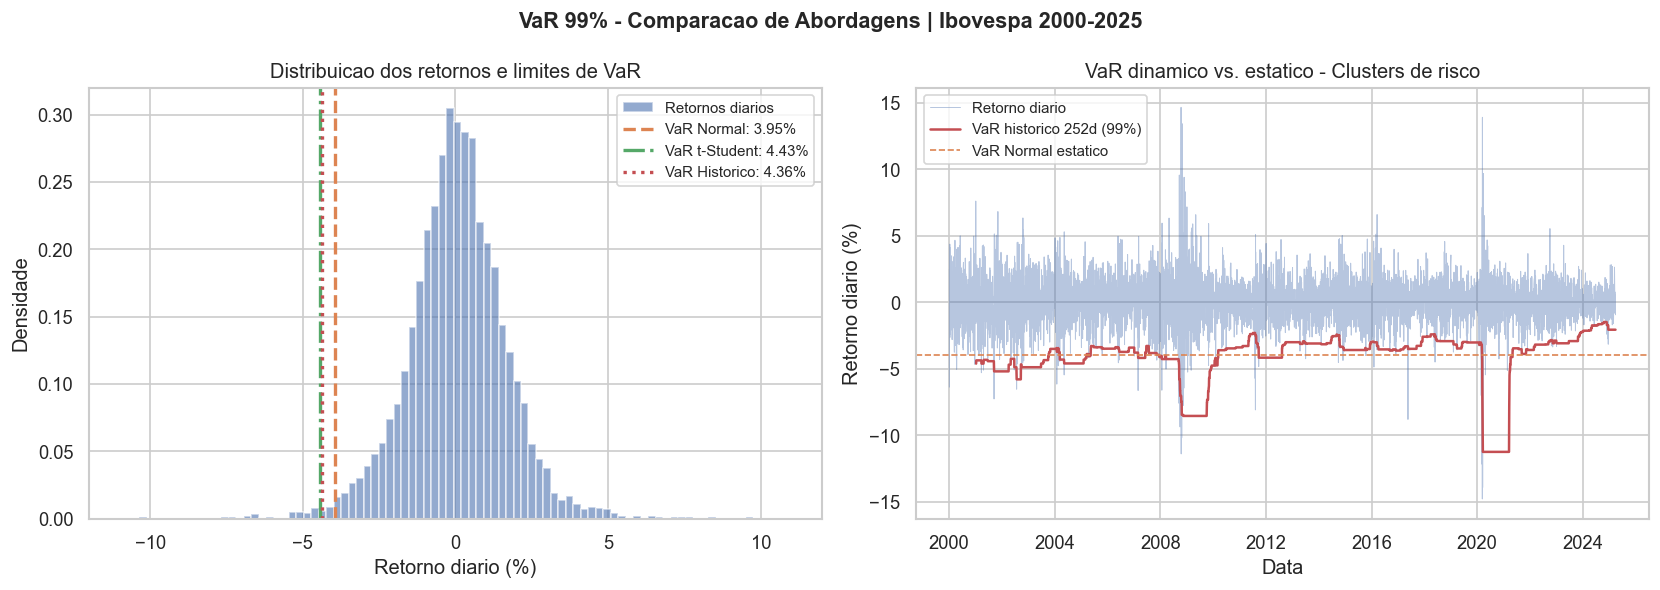

In [11]:
from scipy.stats import t as t_dist, norm

# VaR 99% - tres abordagens
alpha_var = 0.01

# 1. Normal parametrico
var_normal = -(mu_ret + norm.ppf(alpha_var) * sig_ret)

# 2. t de Student parametrico (MLE)
nu_fit, loc_fit, scale_fit = t_dist.fit(ret, floc=mu_ret)
var_t = -(loc_fit + t_dist.ppf(alpha_var, df=nu_fit) * scale_fit)

# 3. Historico (quantil empirico)
var_hist = -np.quantile(ret, alpha_var)

print('=' * 57)
print('  VaR 99% - Abordagens comparadas (retorno diario)')
print('=' * 57)
print(f'  Normal parametrico          : {var_normal*100:.2f}%')
print(f'  t de Student (nu={nu_fit:.1f})      : {var_t*100:.2f}%')
print(f'  Historico (nao-parametrico) : {var_hist*100:.2f}%')
print('=' * 57)

# Backtesting
viol_normal = (ret < -var_normal).mean()
viol_t      = (ret < -var_t).mean()
viol_hist   = (ret < -var_hist).mean()

print(f'\n  Backtesting - Taxa de violacoes vs. esperada ({alpha_var:.0%})')
print(f'  Normal    : {viol_normal:.3%}  (razao: {viol_normal/alpha_var:.2f}x)')
print(f'  t-Student : {viol_t:.3%}  (razao: {viol_t/alpha_var:.2f}x)')
print(f'  Historico : {viol_hist:.3%}  (razao: {viol_hist/alpha_var:.2f}x)')
print('\n  Razao ideal = 1.00x  |  > 1.5x = modelo subestima risco')

# Visualizacao
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VaR 99% - Comparacao de Abordagens | Ibovespa 2000-2025',
             fontsize=13, fontweight='bold')

# Painel esquerdo: histograma + linhas de VaR
ax = axes[0]
ax.hist(ret * 100, bins=120, color='#4C72B0', alpha=0.6,
        density=True, label='Retornos diarios')
ax.axvline(-var_normal * 100, color='#DD8452', lw=2,
           linestyle='--', label=f'VaR Normal: {var_normal*100:.2f}%')
ax.axvline(-var_t * 100, color='#55A868', lw=2,
           linestyle='-.', label=f'VaR t-Student: {var_t*100:.2f}%')
ax.axvline(-var_hist * 100, color='#C44E52', lw=2,
           linestyle=':', label=f'VaR Historico: {var_hist*100:.2f}%')
ax.set_xlabel('Retorno diario (%)')
ax.set_ylabel('Densidade')
ax.set_title('Distribuicao dos retornos e limites de VaR')
ax.set_xlim(-12, 12)
ax.legend(fontsize=9)

# Painel direito: serie temporal + VaR dinamico
ax2 = axes[1]
ret_series = pd.Series(ret, index=retorno.index)
var_roll = ret_series.rolling(252).quantile(alpha_var) * (-1)
ax2.plot(ret_series * 100, color='#4C72B0', alpha=0.4,
         linewidth=0.6, label='Retorno diario')
ax2.plot(-var_roll * 100, color='#C44E52', linewidth=1.5,
         label='VaR historico 252d (99%)')
ax2.axhline(-var_normal * 100, color='#DD8452', linestyle='--',
            linewidth=1, label='VaR Normal estatico')
ax2.set_xlabel('Data')
ax2.set_ylabel('Retorno diario (%)')
ax2.set_title('VaR dinamico vs. estatico - Clusters de risco')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 8.4 O Ecossistema de Inteligência Artificial

Um diagrama frequentemente usado para situar o Machine Learning dentro do campo mais amplo da IA é o de **esferas concêntricas**. Cada camada é um *subconjunto* da anterior:

- **Inteligência Artificial (IA):** campo mais amplo — qualquer sistema que simula capacidades cognitivas humanas
- **Machine Learning (ML):** subconjunto da IA — sistemas que aprendem padrões a partir de dados, sem serem explicitamente programados para cada tarefa
- **Rede Neural Artificial (RNA):** subconjunto do ML — modelos inspirados na estrutura neuronal do cérebro humano
- **Deep Learning (DL):** subconjunto das RNAs — redes com muitas camadas ocultas, capazes de aprender representações hierárquicas dos dados

Estatística clássica e modelos como GARCH/ARIMA vivem **fora** dessas esferas — pertencem ao domínio da Estatística, que é uma disciplina independente que fundamenta e interage com todos os círculos.

![Ecossistema de Inteligência Artificial: IA ⊃ ML ⊃ RNA ⊃ Deep Learning](assets/grafico-cd.webp)

## 9. Resumo

| Conceito | Definição resumida | Aplicação em risco de mercado |
|----------|-------------------|-------------------------------|
| **Probabilidade empírica** | Frequência relativa de eventos históricos | P(queda > 3%) = 3,5% dos pregões |
| **Prob. condicional** | P(A\|B) — probabilidade revisada dado B | P(queda hoje \| queda ontem) |
| **Bayes** | Atualização de crenças com novas evidências | Revisão do prior ao longo do pregão |
| **Bernoulli** | Experimento binário com probabilidade p | Cada pregão: alta (1) ou queda (0) |
| **Binomial** | Soma de n Bernoullis independentes | Dias positivos em 252 pregões |
| **Bimodal** | Distribuição com dois picos (descritivo) | Dois regimes de mercado |
| **Poisson** | Contagem de eventos raros em intervalo | Crashes mensais > 3% |
| **Normal** | Simétrica, parâmetros μ e σ | Hipótese padrão nos modelos de risco |
| **t de Student** | Caudas mais pesadas que a Normal | Modelagem de retornos com fat tails |
| **Caudas longas** | Eventos extremos mais frequentes que o previsto | VaR subestimado pela Normal |
| **Assimetria** | Grau de assimetria da distribuição | Retornos do Ibovespa: S ≈ −0.12 |
| **Curtose** | Peso das caudas relativo à Normal | Ibovespa: Ke ≈ 6.5 (leptocúrtica) |
| **Jarque-Bera** | Teste de normalidade via S e Ke | Rejeita normalidade nos retornos |
| **ADF** | Teste de estacionariedade | Retornos são estacionários (nível) |
| **Ljung-Box** | Teste de autocorrelação | Baixa autocorrelação — mercado eficiente |
| **Estat. vs. ML** | Inferência vs. predição | GARCH (est.) para VaR; LSTM (DL) para previsão |

---

## Referências

- Magalhães, M. N.; Lima, A. C. P. — *Noções de Probabilidade e Estatística* (IME-USP)
- Triola, M. F. — *Introdução à Estatística*
- Morettin, P. A.; Toloi, C. M. — *Análise de Séries Temporais*
- Taleb, N. N. — *The Black Swan* (Random House, 2007)
- Yahoo Finance — Ibovespa (^BVSP)